In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set(style="whitegrid")

# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv('Amazon Sale Report.csv', low_memory=False)



In [2]:
# 2. DATA CLEANING & PREPARATION
# ---------------------------------------------------------
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Handle missing values in Amount (set to 0 for analysis)
df['Amount'] = df['Amount'].fillna(0)

# Drop unnecessary columns (New and PendingS as per common Amazon datasets)
cols_to_drop = ['New', 'PendingS']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


/tmp/ipykernel_19155/1231522342.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


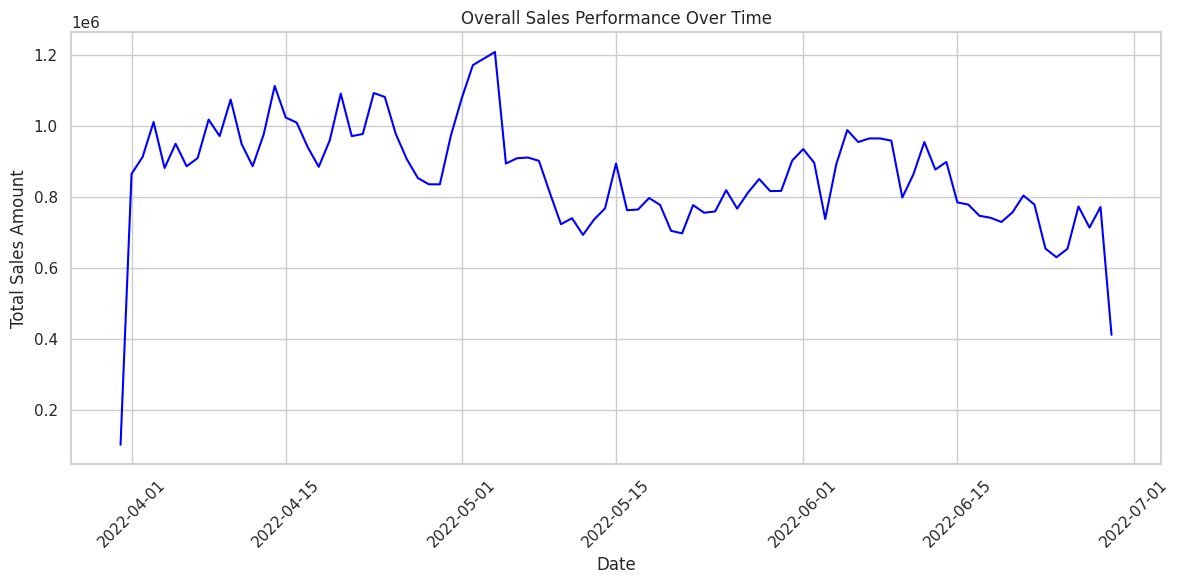

In [3]:
# 3. SALES OVERALL PERFORMANCE (Objective 1)
# ---------------------------------------------------------
daily_sales = df.groupby('Date')['Amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='Date', y='Amount', color='blue')
plt.title('Overall Sales Performance Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_overview.png')
plt.show()


/tmp/ipykernel_19155/119828110.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=category_order, palette='viridis')


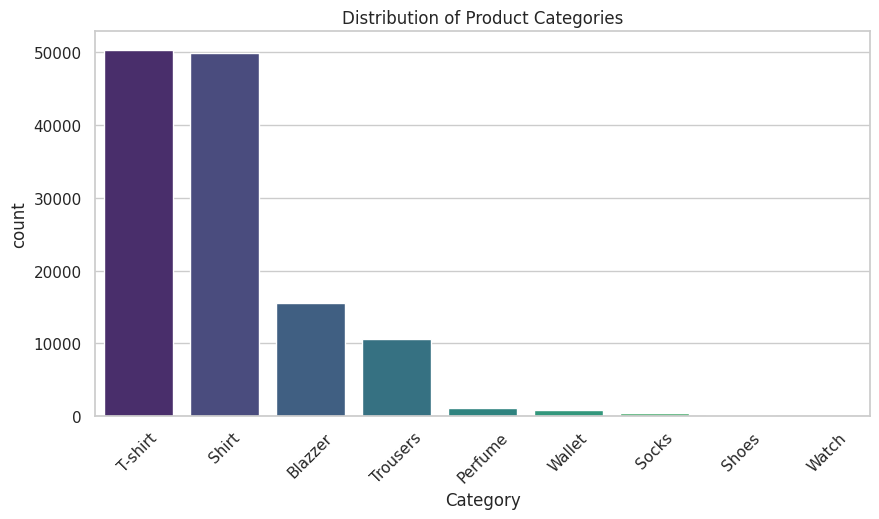

In [4]:
# 4. PRODUCT ANALYSIS (Objective 2)
# ---------------------------------------------------------
# Top Categories by Quantity
plt.figure(figsize=(10, 5))
category_order = df['Category'].value_counts().index
sns.countplot(data=df, x='Category', order=category_order, palette='viridis')
plt.title('Distribution of Product Categories')
plt.xticks(rotation=45)
plt.savefig('product_categories.png')
plt.show()


/tmp/ipykernel_19155/1922088741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Size', order=size_order, palette='magma')


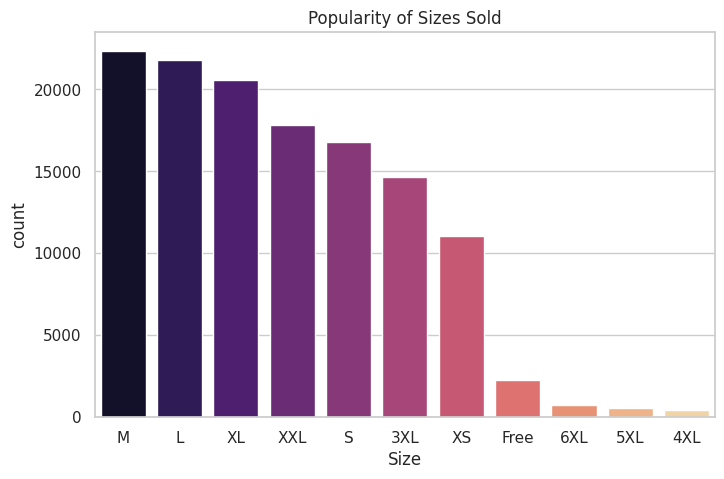

In [5]:
# Size Analysis
plt.figure(figsize=(8, 5))
size_order = df['Size'].value_counts().index
sns.countplot(data=df, x='Size', order=size_order, palette='magma')
plt.title('Popularity of Sizes Sold')
plt.savefig('product_sizes.png')
plt.show()


/tmp/ipykernel_19155/2105647964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fulfilment', palette='Set2')


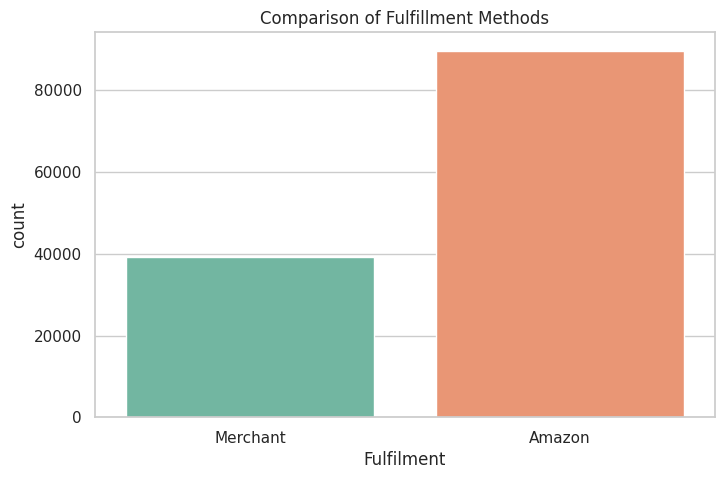

In [6]:
# 5. FULFILLMENT ANALYSIS (Objective 3)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Fulfilment', palette='Set2')
plt.title('Comparison of Fulfillment Methods')
plt.savefig('fulfillment_methods.png')
plt.show()


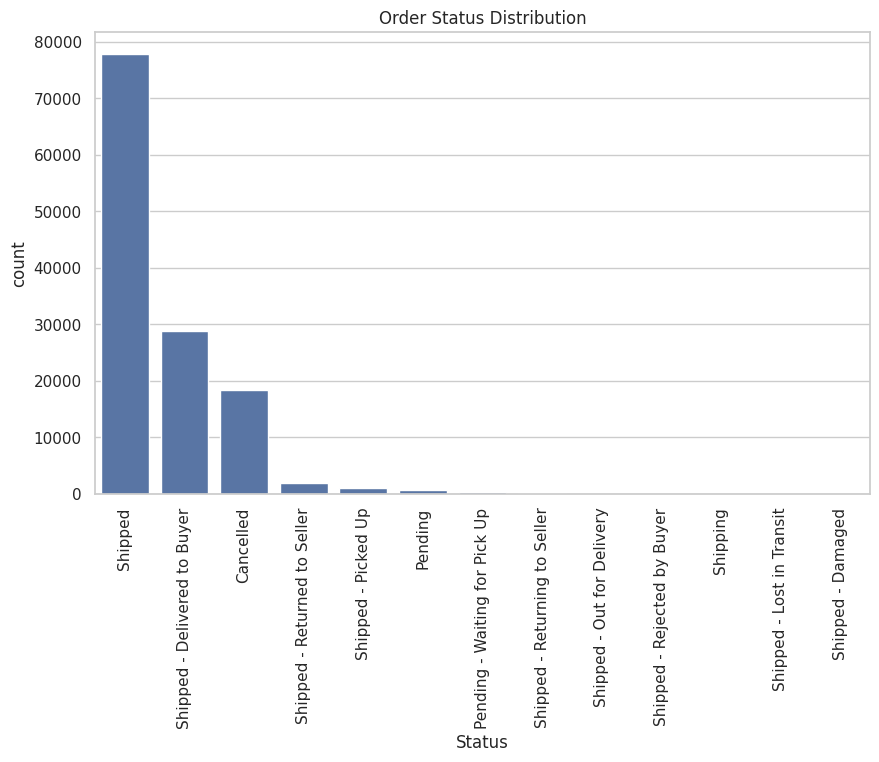

In [7]:
# Order Status Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index)
plt.title('Order Status Distribution')
plt.xticks(rotation=90)
plt.savefig('order_status.png')
plt.show()


/tmp/ipykernel_19155/2443582398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales, x='ship-state', y='Amount', palette='rocket')


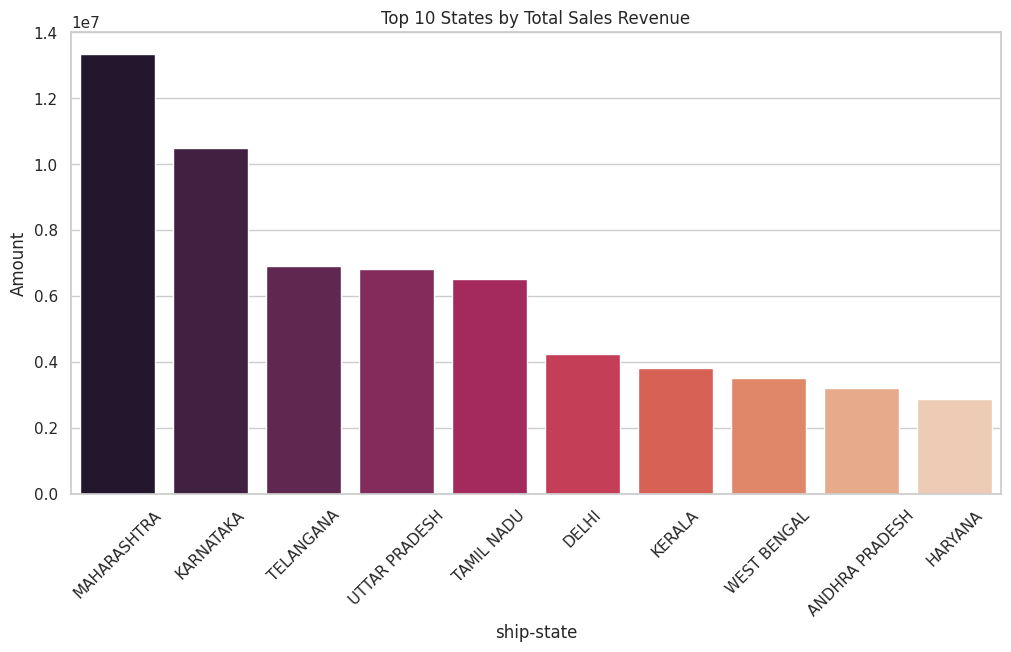

In [8]:
# 6. GEOGRAPHICAL ANALYSIS (Objective 5)
# ---------------------------------------------------------
# Top 10 States by Revenue
state_sales = df.groupby('ship-state')['Amount'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales, x='ship-state', y='Amount', palette='rocket')
plt.title('Top 10 States by Total Sales Revenue')
plt.xticks(rotation=45)
plt.savefig('geographical_sales.png')
plt.show()


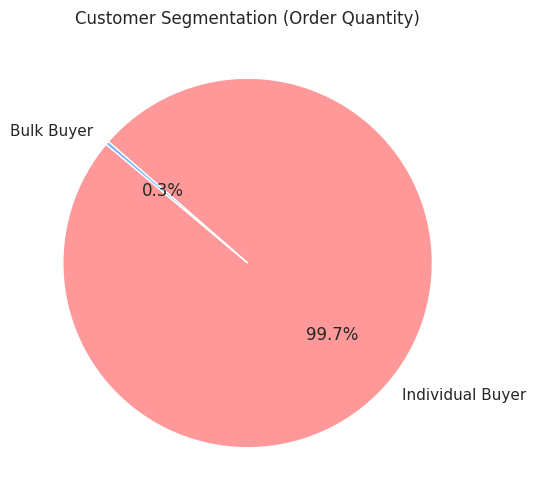

Analysis Complete. Images saved for the report.


In [9]:
# 7. CUSTOMER SEGMENTATION (Objective 4)
# ---------------------------------------------------------
# Segmenting by Buying Behavior (Quantity per Order)
df['Order_Type'] = np.where(df['Qty'] > 1, 'Bulk Buyer', 'Individual Buyer')
segmentation = df['Order_Type'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
plt.pie(segmentation, labels=segmentation.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Customer Segmentation (Order Quantity)')
plt.savefig('customer_segments.png')
plt.show()

print("Analysis Complete. Images saved for the report.")